In [19]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

data_dir = "/home/bbc8731/NetMedGPT/reproduce_plots/results"

In [20]:
# ── Load DTI data (NetMedGPT vs GraphormerDTI) ────────────────────────────────
dti = pd.read_csv("/home/bbc8731/GraphormerDTI/comparison_results/drug_protein_per_seed_5seeds.csv")
nm_dti = dti[dti["model"] == "NetMedGPT"].sort_values("seed")
gd_dti = dti[dti["model"] == "GraphormerDTI"].sort_values("seed")

# ── Load ADR data (NetMedGPT vs MFAHGN) ───────────────────────────────────────
nm_adr_raw = json.load(open("/home/bbc8731/MFAHGN/ADR_comparison/results/netmedgpt_adr_restricted_pool.json"))
nm_adr = {s["seed"]: s for s in nm_adr_raw["seeds"]}
mf_adr = {s: json.load(open(f"/home/bbc8731/MFAHGN/ADR_comparison/results/seed{s}_mfahgn_results.json"))
          for s in range(1, 6)}

def ms(vals):
    return round(float(np.mean(vals)), 3), round(float(np.std(vals, ddof=1)), 3)

# DTI stats
dti_data = {
    "AUPRC":      {"NetMedGPT": ms(nm_dti["aupr"]),       "GraphormerDTI": ms(gd_dti["aupr"])},
    "AUC":        {"NetMedGPT": ms(nm_dti["auc"]),        "GraphormerDTI": ms(gd_dti["auc"])},
    "F1":         {"NetMedGPT": ms(nm_dti["f1"]),         "GraphormerDTI": ms(gd_dti["f1"])},
    "Recall@100": {"NetMedGPT": ms(nm_dti["recall_100"]), "GraphormerDTI": ms(gd_dti["recall_100"])},
}

# ADR stats
adr_data = {
    "AUPRC":      {"NetMedGPT": ms([nm_adr[s]["aupr"]       for s in range(1,6)]),
                   "MFAHGN":    ms([mf_adr[s]["aupr"]        for s in range(1,6)])},
    "AUC":        {"NetMedGPT": ms([nm_adr[s]["auroc"]      for s in range(1,6)]),
                   "MFAHGN":    ms([mf_adr[s]["auroc"]       for s in range(1,6)])},
    "F1":         {"NetMedGPT": ms([nm_adr[s]["f1"]         for s in range(1,6)]),
                   "MFAHGN":    ms([mf_adr[s]["f1"]          for s in range(1,6)])},
    "Recall@100": {"NetMedGPT": ms([nm_adr[s]["recall_100"] for s in range(1,6)]),
                   "MFAHGN":    ms([mf_adr[s]["recall_100"]  for s in range(1,6)])},
}

Saved: /home/bbc8731/NetMedGPT/reproduce_plots/results/dti_adr_comparison.png


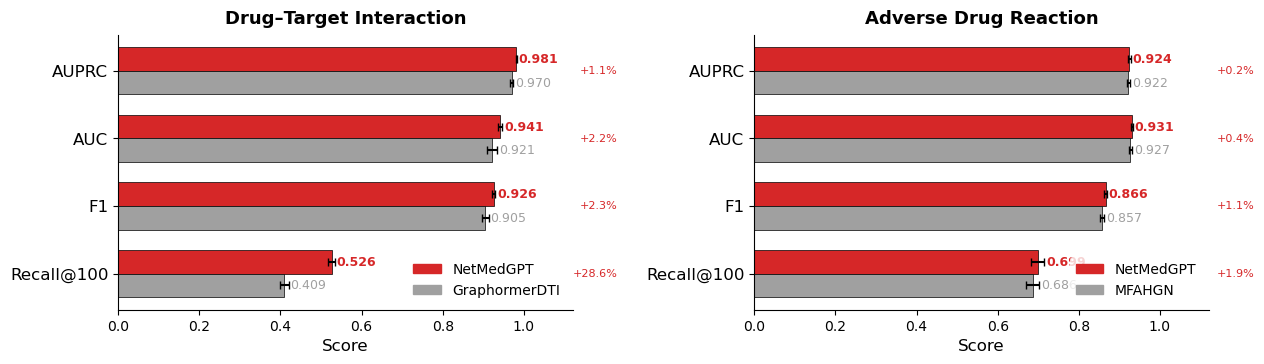

In [21]:
NM_COLOR   = "#D62728"
COMP_COLOR = "#A0A0A0"

def plot_panel(ax, data, comp_name, title):
    metrics   = list(data.keys())
    n         = len(metrics)
    bar_height = 0.35
    y_group   = np.arange(n)

    for gi, metric in enumerate(metrics):
        nm_mean,   nm_std   = data[metric]["NetMedGPT"]
        comp_mean, comp_std = data[metric][comp_name]

        # sort so higher performer is first (bi=0)
        pairs = sorted(
            [(nm_mean, nm_std, "NetMedGPT"), (comp_mean, comp_std, comp_name)],
            reverse=True
        )

        for bi, (mean, std, method) in enumerate(pairs):
            y     = gi + (bi - 0.5) * bar_height
            color = NM_COLOR if method == "NetMedGPT" else COMP_COLOR
            ax.barh(y, mean, xerr=std, height=bar_height,
                    color=color, capsize=3, edgecolor="black",
                    linewidth=0.5)
            ax.text(mean + std + 0.005, y,
                    f"{mean:.3f}", va="center", fontsize=9,
                    color=color, fontweight="bold" if method == "NetMedGPT" else "normal")

        # % improvement annotation per metric
        if nm_mean != comp_mean:
            base = comp_mean
            imp  = (nm_mean - base) / base * 100
            sign = "+" if imp > 0 else ""
            ax.text(1.10, gi, f"{sign}{imp:.1f}%",
                    va="center", ha="right", fontsize=8,
                    color=NM_COLOR if imp > 0 else COMP_COLOR,
                    transform=ax.get_yaxis_transform())

    ax.set_yticks(y_group)
    ax.set_yticklabels(metrics, fontsize=12)
    ax.invert_yaxis()
    ax.set_xlim(0, 1.12)
    ax.set_xlabel("Score", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    handles = [mpatches.Patch(color=NM_COLOR,   label="NetMedGPT"),
               mpatches.Patch(color=COMP_COLOR, label=comp_name)]
    ax.legend(handles=handles, fontsize=10, loc="lower right",
              framealpha=0.8, edgecolor="none")


fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_panel(axes[0], dti_data, "GraphormerDTI", "Drug–Target Interaction")
plot_panel(axes[1], adr_data, "MFAHGN",        "Adverse Drug Reaction")

plt.tight_layout(pad=2.0)

out_png = os.path.join(data_dir, "dti_adr_comparison.png")
out_pdf = os.path.join(data_dir, "dti_adr_comparison.pdf")
plt.savefig(out_png, bbox_inches="tight", dpi=300)
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
print(f"Saved: {out_png}")
plt.show()

Saved: /home/bbc8731/NetMedGPT/reproduce_plots/results/dti_adr_comparison_no_text.png


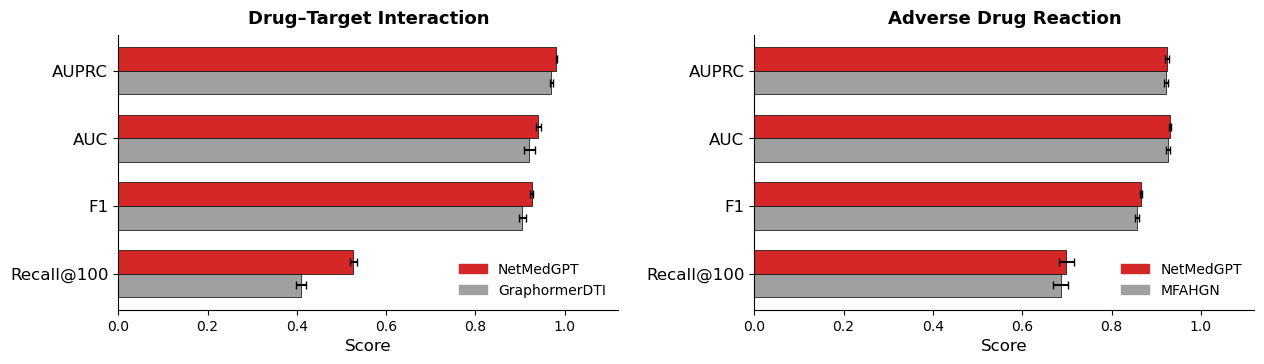

In [22]:
def plot_panel_no_text(ax, data, comp_name, title):
    metrics   = list(data.keys())
    n         = len(metrics)
    bar_height = 0.35
    y_group   = np.arange(n)

    for gi, metric in enumerate(metrics):
        nm_mean,   nm_std   = data[metric]["NetMedGPT"]
        comp_mean, comp_std = data[metric][comp_name]

        pairs = sorted(
            [(nm_mean, nm_std, "NetMedGPT"), (comp_mean, comp_std, comp_name)],
            reverse=True
        )

        for bi, (mean, std, method) in enumerate(pairs):
            y     = gi + (bi - 0.5) * bar_height
            color = NM_COLOR if method == "NetMedGPT" else COMP_COLOR
            ax.barh(y, mean, xerr=std, height=bar_height,
                    color=color, capsize=3, edgecolor="black",
                    linewidth=0.5)

    ax.set_yticks(y_group)
    ax.set_yticklabels(metrics, fontsize=12)
    ax.invert_yaxis()
    ax.set_xlim(0, 1.12)
    ax.set_xlabel("Score", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    handles = [mpatches.Patch(color=NM_COLOR,   label="NetMedGPT"),
               mpatches.Patch(color=COMP_COLOR, label=comp_name)]
    ax.legend(handles=handles, fontsize=10, loc="lower right",
              framealpha=0.8, edgecolor="none")


fig2, axes2 = plt.subplots(1, 2, figsize=(13, 4))

plot_panel_no_text(axes2[0], dti_data, "GraphormerDTI", "Drug–Target Interaction")
plot_panel_no_text(axes2[1], adr_data, "MFAHGN",        "Adverse Drug Reaction")

plt.tight_layout(pad=2.0)

out_png2 = os.path.join(data_dir, "dti_adr_comparison_no_text.png")
out_pdf2 = os.path.join(data_dir, "dti_adr_comparison_no_text.pdf")
plt.savefig(out_png2, bbox_inches="tight", dpi=300)
plt.savefig(out_pdf2, bbox_inches="tight", dpi=300)
print(f"Saved: {out_png2}")
plt.show()